<a href="https://colab.research.google.com/github/krishnakanthkona-3110/AI-ML-Learning-Journey/blob/main/Dynamic_Programming/DSA_Dynamic_Programming_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Important point - When ever if we want to do an recursion on an array, we need to use index.

No. of variables is equal to number of dimensions of the array.

# 1Q). Unique Paths

In [1]:
# Recursion solution

class Solution:
    def uniquePaths(self, n, m):

        def solve(i, j):

            # reached destination
            if i == n-1 and j == m-1:
                return 1

            # out of bounds
            if i >= n or j >= m:
                return 0

            down = solve(i+1, j)
            right = solve(i, j+1)

            return down + right

        return solve(0, 0)

In [2]:
sol = Solution()
sol.uniquePaths(3,3)

6

In [3]:
sol.uniquePaths(2,3)

3

Time complexity - O(2^(n+m))

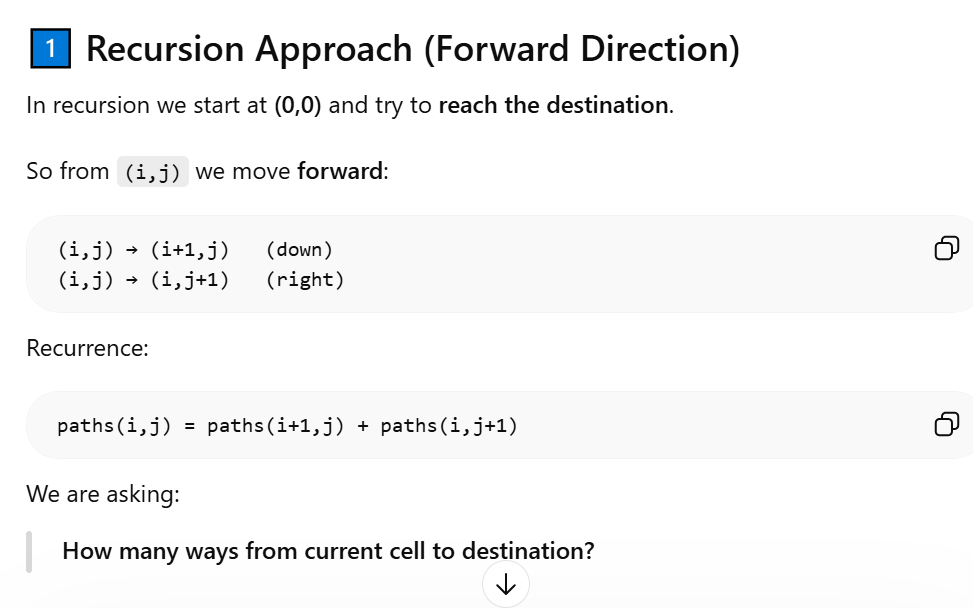

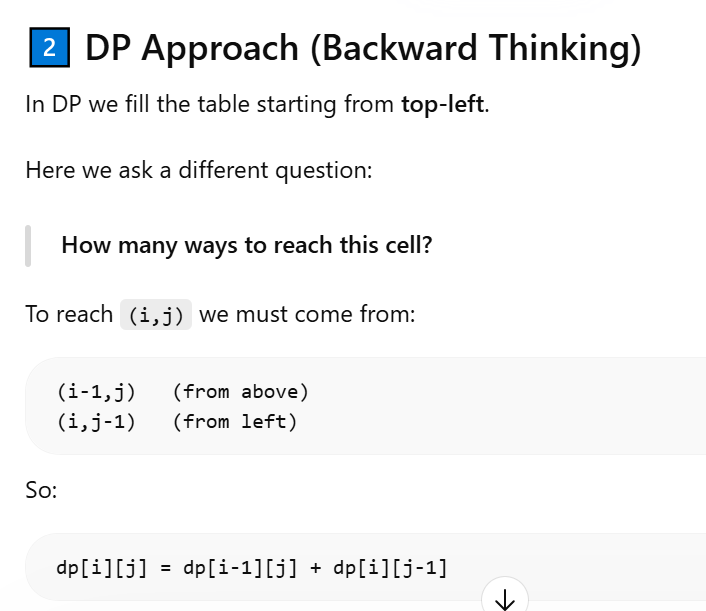

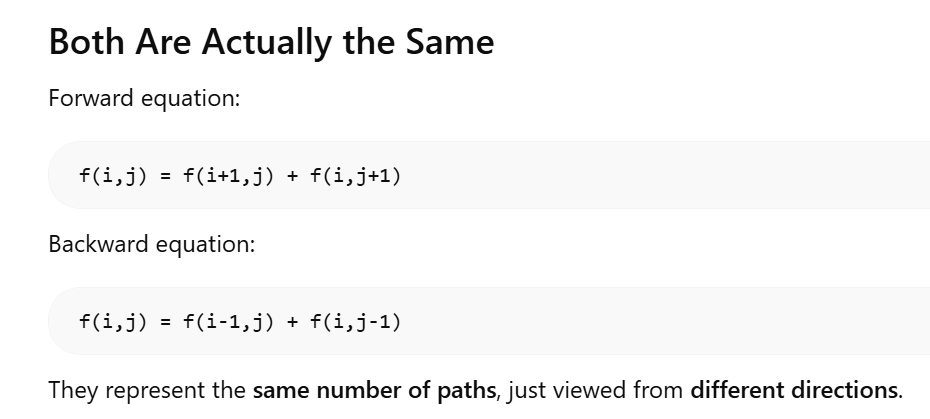

In [24]:
def dppaths(n, m):

        # Create a DP table of size n x m
        dp = [[0]*m for _ in range(n)]

        # Base Case 1:
        for j in range(m):
            dp[0][j] = 1

        # Base Case 2:
        for i in range(n):
            dp[i][0] = 1

        # Fill the remaining cells in the DP table
        for i in range(1, n):
            for j in range(1, m):

                dp[i][j] = dp[i-1][j] + dp[i][j-1]

        return dp[n-1][m-1]

In [22]:
# Using Dynamic Programming

def dppaths(n, m):

        # Create a DP table of size n x m
        # dp[i][j] will store the number of ways to reach cell (i,j)
        dp = [[0]*m for _ in range(n)]

        # Base Case 1:
        # First row → you can only move RIGHT to reach these cells
        # So there is exactly 1 way to reach every cell in the first row
        for j in range(m):
            dp[0][j] = 1

        # Base Case 2:
        # First column → you can only move DOWN to reach these cells
        # So there is exactly 1 way to reach every cell in the first column
        for i in range(n):
            dp[i][0] = 1

        # Fill the remaining cells in the DP table
        for i in range(1, n):
            for j in range(1, m):

                # To reach (i,j), you can come from:
                # 1. The cell above → (i-1, j)
                # 2. The cell on the left → (i, j-1)

                dp[i][j] = dp[i-1][j] + dp[i][j-1]

        # The bottom-right cell contains the total number of unique paths
        return dp[n-1][m-1]



In [23]:
dppaths(3,3)

6

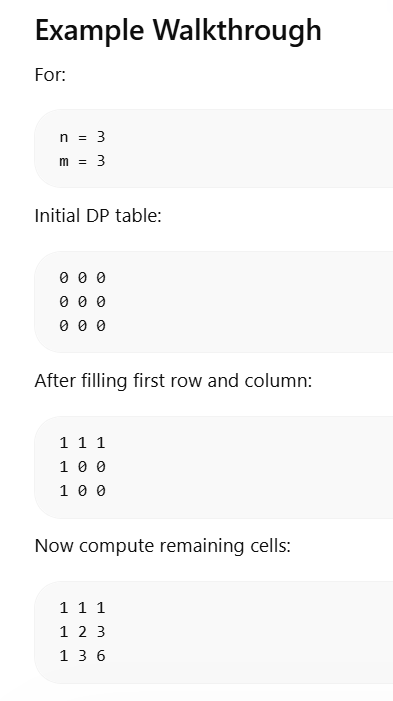

Time and Space Complexity = O(n*m)

In [11]:
def uniquecc(n, m):

        dp = [1]*m

        for i in range(1,n):
            for j in range(1,m):
                dp[j] = dp[j] + dp[j-1]

        return dp[m-1]

In [12]:
uniquecc(3,3)

6

Time complexity - O(n*m)

Space complexity - O(m)

In [19]:
def uniquecc(n, m):

    # Create a 1D DP array of size m
    # dp[j] represents the number of ways to reach column j
    # in the current row
    dp = [1] * m

    # Why initialize with 1?
    # For the first row, we can only move RIGHT.
    # So there is exactly 1 way to reach every cell in the first row.

    # Loop through remaining rows
    for i in range(1, n):

        # Start from column 1 because column 0 always has 1 way
        # (you can only reach it by moving DOWN)
        for j in range(1, m):

            # dp[j] → number of ways from TOP
            # dp[j-1] → number of ways from LEFT

            # Update ways to reach current cell
            dp[j] = dp[j] + dp[j-1]

    # Last element contains number of ways to reach (n-1, m-1)
    return dp[m-1]

# 2Q). Count A-digit numbers such that:

Sum of digits = B

Leading digit cannot be 0 (must be 1–9)

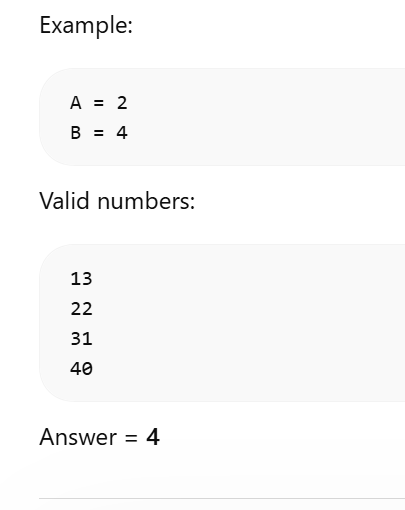

# You are given:

coins = [c1, c2, c3...]

amount

Find the minimum number of coins required to make the given amount.
If not possible → return -1.

In [26]:
def coin_change(coins, amount):

    # dp[i] = minimum coins required to make amount i
    # Initialize with infinity (means not reachable yet)
    dp = [float('inf')] * (amount + 1)

    # Base case:
    # 0 coins are needed to make amount 0
    dp[0] = 0

    # Iterate through each coin
    for coin in coins:

        # Try forming all amounts starting from this coin value
        for current_amount in range(coin, amount + 1):

            # Two options:
            # 1. Keep previous value dp[current_amount]
            # 2. Use this coin → dp[current_amount - coin] + 1

            dp[current_amount] = min(
                dp[current_amount],
                dp[current_amount - coin] + 1
            )

    # If still infinity → amount cannot be formed
    if dp[amount] == float('inf'):
        return -1
    else:
        return dp[amount]

In [27]:
coin_change([1,2,3], 10)

4

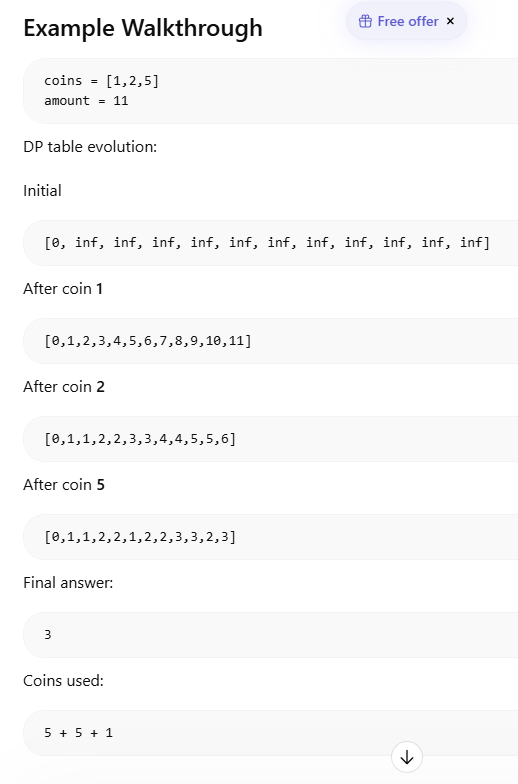

Time Complexity - O(N × amount)

Space Complaexity - O(N × amount)